<a href="https://colab.research.google.com/github/Assaoka/Decolar--Introducao_a_Ciencia_de_Dados/blob/main/%5B%20%208%20%5D%20Decifrando%20Padr%C3%B5es%20e%20Rela%C3%A7%C3%B5es%20com%20Gr%C3%A1ficos%20/%20Decifrando%20Padr%C3%B5es%20e%20Rela%C3%A7%C3%B5es%20com%20Gr%C3%A1ficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 8: Decifrando Padrões e Relações com Gráficos

Na aula passada, dominamos a arte de limpar, agrupar e preparar nossos dados. Agora que eles estão prontos, vamos aprender a fazê-los "falar". A melhor forma de entender a história que os dados contam é através da **visualização**.

Hoje, vamos aprender a criar os gráficos essenciais para qualquer análise de dados. Começaremos com os gráficos de **Barra** e **Pizza** para entender categorias. Depois, mergulharemos no **Histograma** para analisar distribuições e, por fim, no **Gráfico de Dispersão** para descobrir relações entre as variáveis.


## 1. Preparando o Ambiente

Vamos importar todas as bibliotecas que precisaremos hoje, incluindo o `Numpy` para criar dados artificiais para as nossas explicações teóricas.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mean, median, mode

# Configurações para melhorar a aparência dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6) # Define um tamanho padrão para os gráficos

# Carregando nossos dados
endereco = 'https://raw.githubusercontent.com/Assaoka/Decolar--Introducao_a_Ciencia_de_Dados/refs/heads/main/pokemon.csv'
df = pd.read_csv(endereco)
df.sample(5)

,Name,National Dex #,Primary Typing,Secondary Typing,Secondary Typing Flag,Generation,Legendary Status,Form,Alt Form Flag,Evolution Stage,...,Weight (hg),Height (in),Weight (lbs),Base Stat Total,Health,Attack,Defense,Special Attack,Special Defense,Speed
214,croconaw,159,water,NaN,False,generation-ii,False,Base,False,2,...,250,43,55,405,65,80,80,59,63,58
414,altaria-mega,334,dragon,fairy,True,generation-iii,True,Mega,True,2,...,206,59,45,590,75,110,110,110,105,80
975,gossifleur,829,grass,NaN,False,generation-viii,False,Base,False,1,...,22,16,5,250,40,40,60,40,60,10
555,lumineon,457,water,NaN,False,generation-iv,False,Base,False,2,...,240,47,53,460,69,69,76,69,86,91
266,steelix,208,steel,ground,True,generation-ii,False,Base,False,2,...,4000,362,882,510,75,85,200,55,65,30


## 2. Revisão Rápida: Poderes da Aula 7

Na última aula, aprendemos a:

1. **`.fillna()`**: Tratar valores ausentes em nosso DataFrame.
    
2. **`.groupby()`**: Agrupar dados com base em uma ou mais colunas para aplicar funções de agregação (`.mean()`, `.max()`, `.size()`, etc.).
    
3. **`.agg()`**: Aplicar múltiplas agregações de uma só vez.
    
4. **`pd.get_dummies()`**: Transformar variáveis categóricas em um formato numérico, essencial para Machine Learning.

## 3. Visualizando Categorias



Vamos começar com os gráficos mais diretos, usados para contar e comparar categorias.



### 3.1. Gráfico de Barras e Gráfico de Pizza



- **Gráfico de Barras:** Perfeito para **comparar** a contagem entre diferentes categorias. É fácil ver qual categoria tem mais ou menos itens.

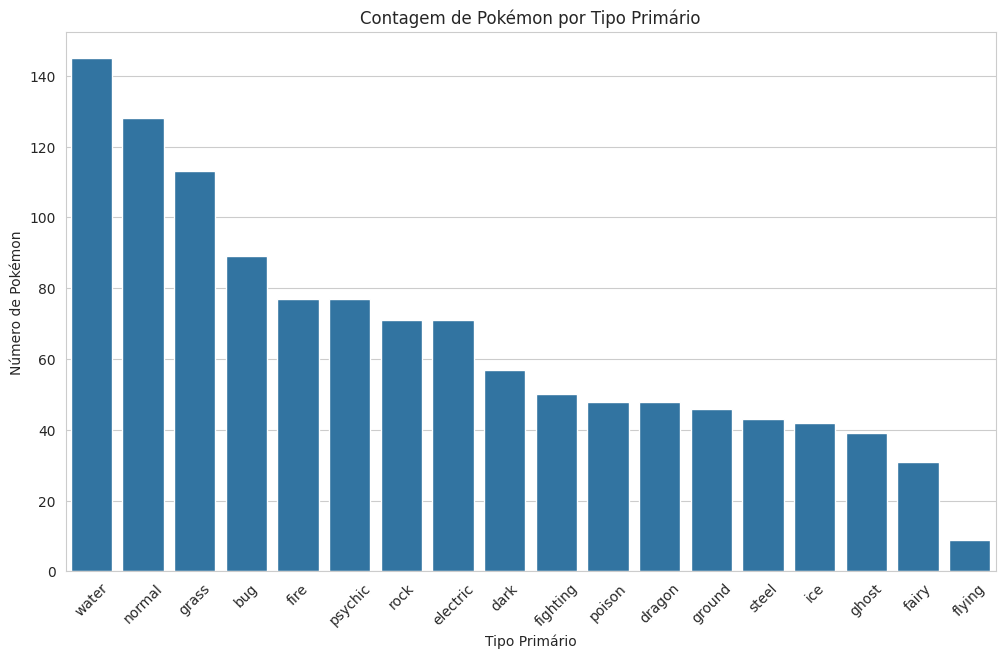

In [3]:
# --- Gráfico de Barras: Contagem de Pokémon por Tipo Primário ---
plt.figure(figsize=(12, 7))
contagem_tipos = df['Primary Typing'].value_counts()
sns.barplot(x=contagem_tipos.index, y=contagem_tipos.values)
plt.title('Contagem de Pokémon por Tipo Primário')
plt.xlabel('Tipo Primário')
plt.ylabel('Número de Pokémon')
plt.xticks(rotation=45)
plt.show()

- **Gráfico de Pizza:** Perfeito para mostrar a **proporção** de cada categoria em relação ao todo. Funciona melhor com poucas categorias.
    

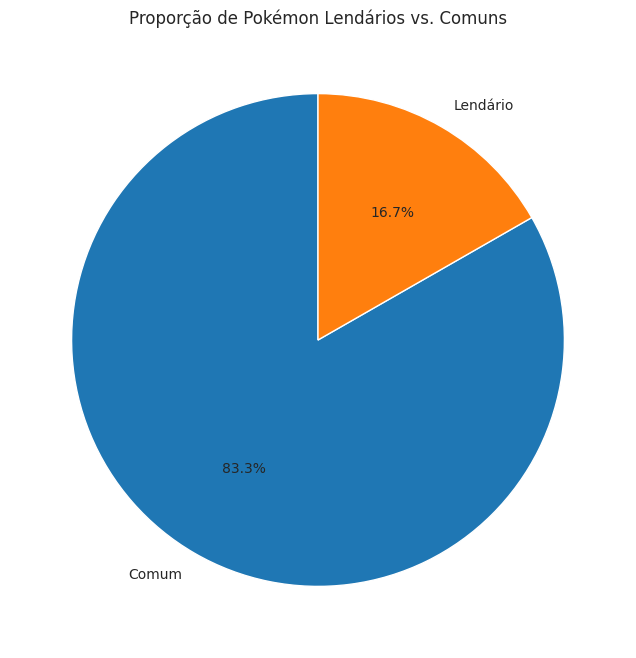

In [4]:
# --- Gráfico de Pizza: Proporção de Pokémon Lendários ---
plt.figure(figsize=(8, 8))
contagem_lendarios = df['Legendary Status'].value_counts()
plt.pie(contagem_lendarios, labels=['Comum', 'Lendário'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Pokémon Lendários vs. Comuns')
plt.show()

## 4. Visualizando Distribuições (Histogramas)


### 4.1. Média, Mediana e Moda

Imagine os stats de `Attack` de cinco Pokémon: `[10, 20, 25, 25, 100]`.

- **Média:** É o centro de gravidade dos dados. Some tudo e divida pela contagem. `(10+20+25+25+100) / 5 = 36`. A média é muito sensível a valores extremos (outliers), como o Pokémon com 100 de ataque.
    
- **Mediana (Percentil 50):** É o valor que está exatamente no meio da fila, após ordenar os dados. Na nossa fila `[10, 20, **25**, 25, 100]`, a mediana é **25**. Ela não é afetada por outliers.
    
- **Moda:** É o valor que mais se repete. No nosso caso, é **25**.
    

In [5]:
attack = [10, 20, 25, 25, 100]
print(f'Média: {mean(attack)}')
print(f'Mediana: {median(attack)}')
print(f'Moda: {mode(attack)}')

Média: 36
Mediana: 25
Moda: 25


### 4.2. Tipos de Distribuição

Vamos criar dados do zero para entender as "formas" mais comuns que eles podem ter.

#### a) Distribuição Uniforme

Todos os resultados são igualmente prováveis. Pense em um dado perfeito.


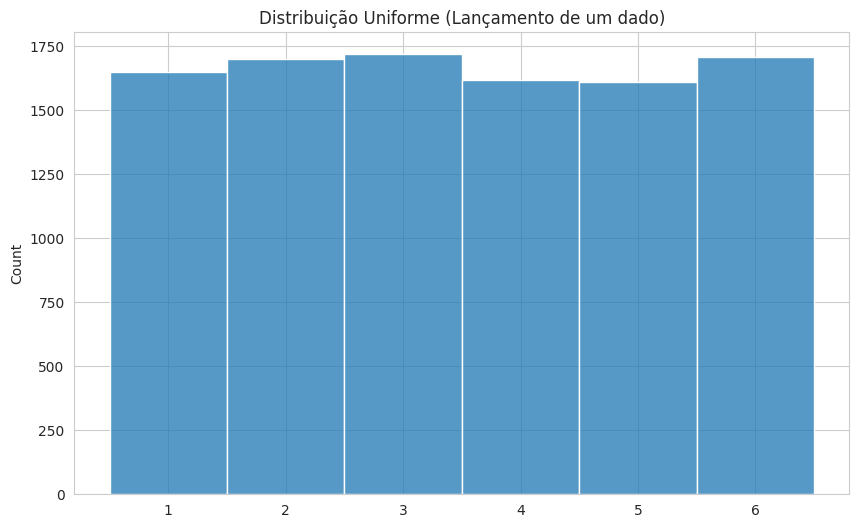

In [8]:
# Simulação do lançamento de um dado 10.000 vezes
dados_uniformes = np.random.randint(1, 7, 10000)
sns.histplot(dados_uniformes, bins=6, discrete=True)
plt.title('Distribuição Uniforme (Lançamento de um dado)')
plt.show()

#### b) Distribuição Normal (Curva de Sino)



É a forma mais comum na natureza. A maioria dos valores se concentra no centro, e valores extremos são raros. **Na distribuição normal perfeita, Média = Mediana = Moda**.


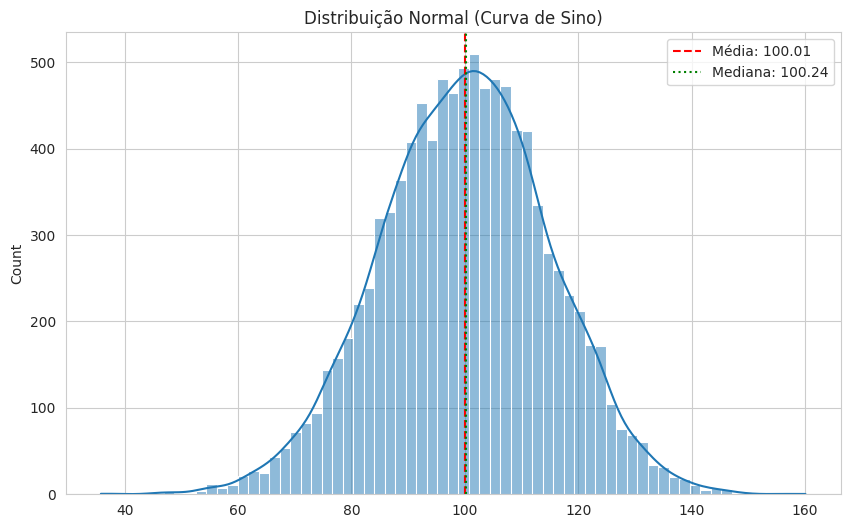

In [9]:
# Simulação de dados com distribuição normal
dados_normais = np.random.normal(loc=100, scale=15, size=10000) # loc=média, scale=desvio padrão
sns.histplot(dados_normais, kde=True)
plt.title('Distribuição Normal (Curva de Sino)')
plt.axvline(np.mean(dados_normais), color='red', linestyle='--', label=f'Média: {np.mean(dados_normais):.2f}')
plt.axvline(np.median(dados_normais), color='green', linestyle=':', label=f'Mediana: {np.median(dados_normais):.2f}')
plt.legend()
plt.show()

#### c) Distribuição Assimétrica (Skewed)



Acontece quando os dados se concentram em um dos lados, deixando uma "cauda" longa no outro. Se a cauda está à direita, a assimetria é à direita.

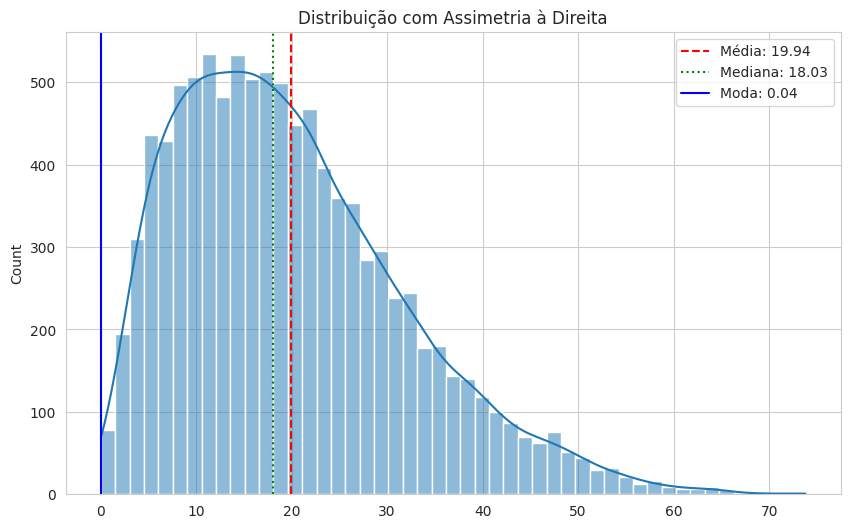

In [13]:
# Simulação de dados com assimetria à direita
dados_assimetricos = np.random.beta(a=2, b=8, size=10000) * 100
sns.histplot(dados_assimetricos, kde=True)
plt.title('Distribuição com Assimetria à Direita')
plt.axvline(np.mean(dados_assimetricos), color='red', linestyle='--', label=f'Média: {np.mean(dados_assimetricos):.2f}')
plt.axvline(np.median(dados_assimetricos), color='green', linestyle=':', label=f'Mediana: {np.median(dados_assimetricos):.2f}')
plt.axvline(pd.Series(dados_assimetricos).mode()[0], color='blue', linestyle='-', label=f'Moda: {pd.Series(dados_assimetricos).mode()[0]:.2f}')
plt.legend()
plt.show()


Note como a Média é "puxada" pela cauda longa. A ordem geralmente é: **Moda < Mediana < Média**.

### 4.3. Aplicação: As Distribuições na Pokédex

#### a) Contagem por Geração:

- **Quase Uniforme: Contagem por Geração** A quantidade de Pokémon por geração não é perfeitamente uniforme, mas não há uma concentração óbvia em uma única geração.

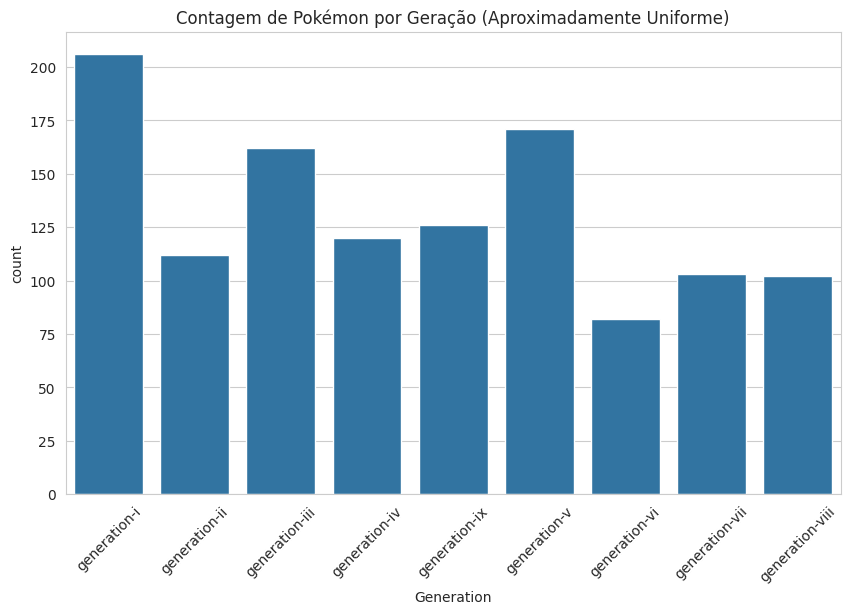

In [14]:
sns.countplot(data=df, x='Generation', order=sorted(df['Generation'].unique()))
plt.title('Contagem de Pokémon por Geração (Aproximadamente Uniforme)')
plt.xticks(rotation=45)
plt.show()

#### b) Soma dos Status Base



- **Normal: O `Base Stat Total`** A soma de vários fatores (Attack, Defense...) tende a uma distribuição normal.

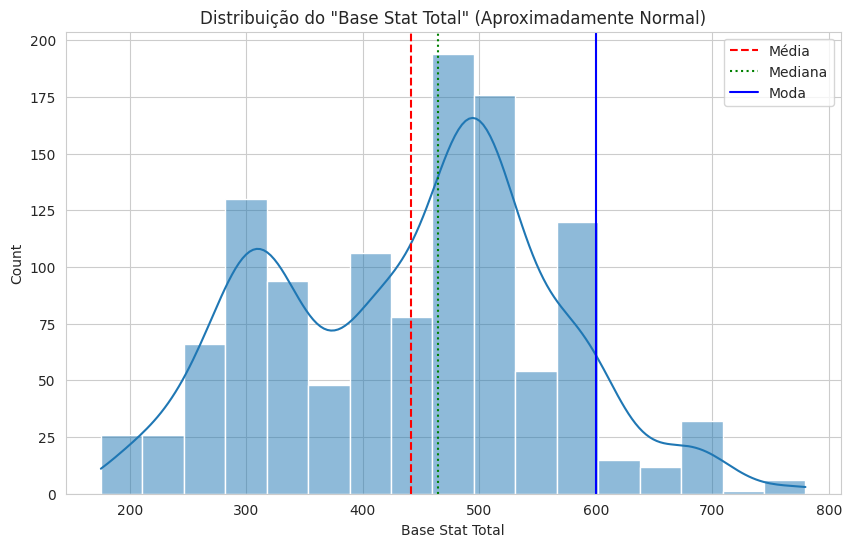

In [15]:
sns.histplot(data=df, x='Base Stat Total', kde=True)
plt.title('Distribuição do "Base Stat Total" (Aproximadamente Normal)')
plt.axvline(df['Base Stat Total'].mean(), color='red', linestyle='--', label='Média')
plt.axvline(df['Base Stat Total'].median(), color='green', linestyle=':', label='Mediana')
plt.axvline(df['Base Stat Total'].mode()[0], color='blue', linestyle='-', label='Moda')
plt.legend()
plt.show()

##### Teorema do Limite Central:

Por que a soma de stats (`Base Stat Total`) tende a uma distribuição normal? O Teorema do Limite Central diz que, quando somamos muitas variáveis aleatórias, a distribuição da soma se aproxima de uma normal, não importa a forma das distribuições originais! É uma das ideias mais importantes da estatística.


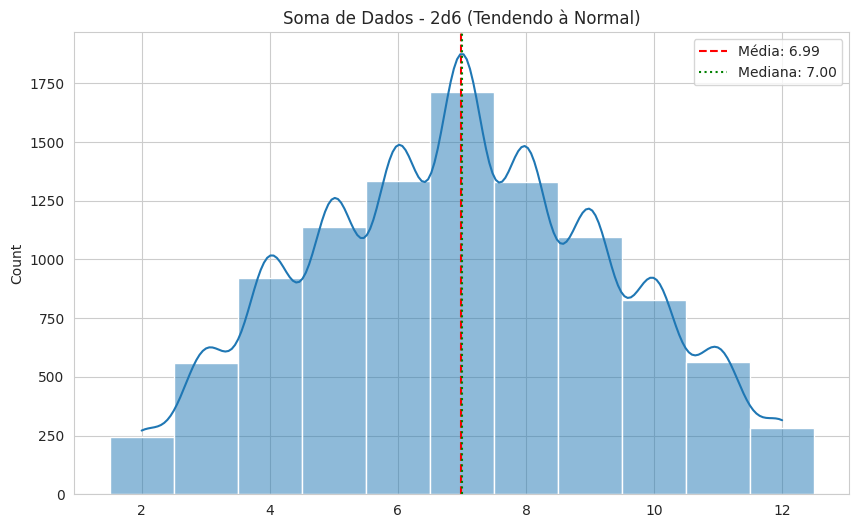

In [16]:
# Simulação da soma do resultado de dois dados (2d6)
dados_soma = np.random.randint(1, 7, 10000) + np.random.randint(1, 7, 10000)
sns.histplot(dados_soma, kde=True, bins=11, discrete=True)
plt.title('Soma de Dados - 2d6 (Tendendo à Normal)')
plt.axvline(np.mean(dados_soma), color='red', linestyle='--', label=f'Média: {np.mean(dados_soma):.2f}')
plt.axvline(np.median(dados_soma), color='green', linestyle=':', label=f'Mediana: {np.median(dados_soma):.2f}')
plt.legend()
plt.show()

#### c) Peso dos Pokemons



- **Assimétrica: O Peso (`Weight (hg)`)** A maioria dos Pokémon é leve, mas uma minoria é extremamente pesada, criando uma forte assimetria à direita.


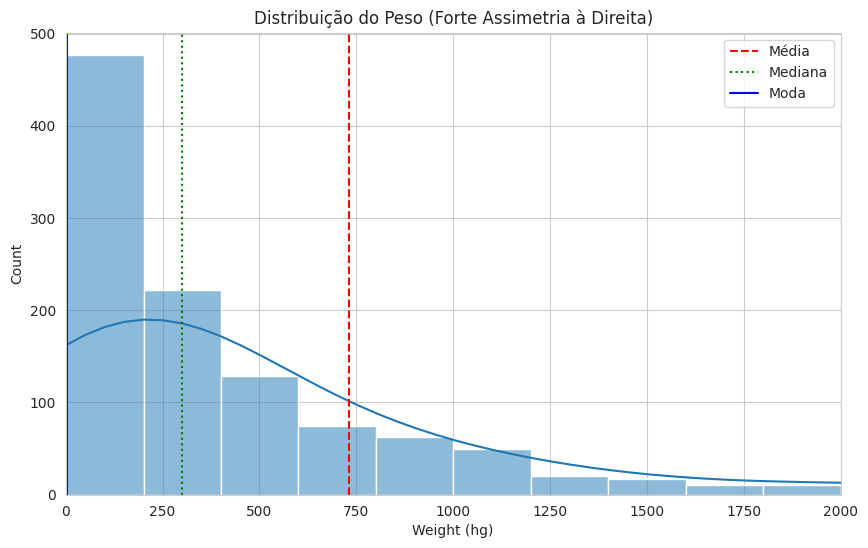

In [17]:
sns.histplot(data=df, x='Weight (hg)', bins=50, kde=True)
plt.title('Distribuição do Peso (Forte Assimetria à Direita)')
plt.xlim(0, 2000) # Limitando o eixo X para melhor visualização
plt.axvline(df['Weight (hg)'].mean(), color='red', linestyle='--', label='Média')
plt.axvline(df['Weight (hg)'].median(), color='green', linestyle=':', label='Mediana')
plt.axvline(df['Weight (hg)'].mode()[0], color='blue', linestyle='-', label='Moda')
plt.legend()
plt.show()

## 5. Visualizando Relações (Gráfico de Dispersão)



Um gráfico de dispersão nos ajuda a ver se existe e qual é a **correlação** (relação) entre duas variáveis numéricas.

**ATENÇÃO: correlação não significa causalidade!**

- **Mais bombeiros no incêndio -> Maior número de mortes:** Isso é uma **correlação espúria devido a uma variável de confusão**. A variável "escondida" é o **tamanho do incêndio**. Incêndios maiores precisam de mais bombeiros e, infelizmente, podem causar mais danos.
    
- **Número de filmes do Nicolas Cage -> Mortes por afogamento:** Este é um exemplo de **correlação espúria** ou **ilusória**. Duas variáveis podem apresentar uma tendência semelhante ao longo do tempo puramente por coincidência, sem que uma tenha qualquer influência sobre a outra.


### 5.1. Tipos de Correlação

In [18]:
# Gerando dados artificiais para os exemplos
x = np.linspace(0, 10, 100)
ruido_fraco = np.random.normal(0, 1, 100)
ruido_forte = np.random.normal(0, 4, 100)

# Criando um DataFrame para facilitar a plotagem
dados_corr = pd.DataFrame({
    'x': x,
    'Positiva Forte': x + ruido_fraco,
    'Positiva Fraca': x + ruido_forte,
    'Negativa Forte': -x + ruido_fraco,
    'Sem Correlação': np.random.uniform(0, 10, 100),
    'Não Linear': (x-5)**2 + ruido_fraco
})

#### a) Positiva Forte

Quando a variável X aumenta, a variável Y também aumenta, e os pontos estão bem próximos de uma linha reta imaginária.


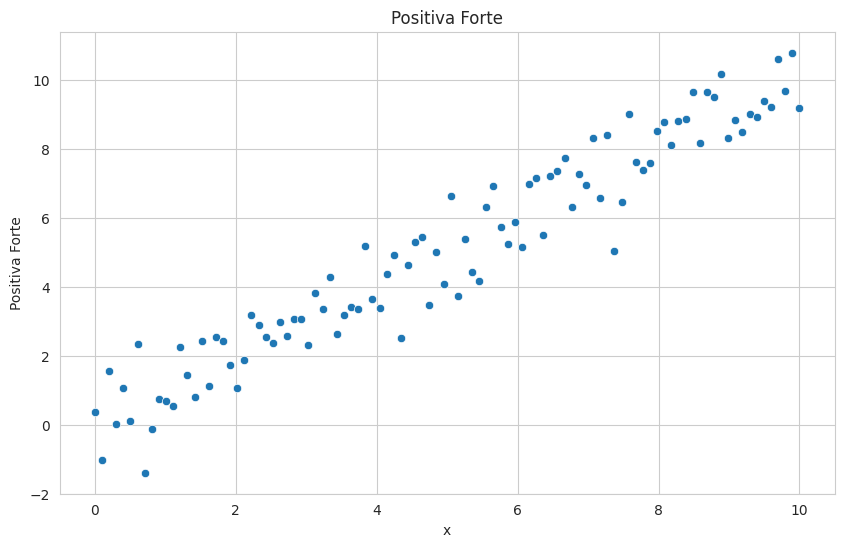

In [19]:
sns.scatterplot(data=dados_corr, x='x', y='Positiva Forte').set_title('Positiva Forte')
plt.show()


#### b) Positiva Fraca

Quando a variável X aumenta, a variável Y também tende a aumentar, mas os pontos estão mais espalhados. A tendência ainda é visível, mas menos definida.

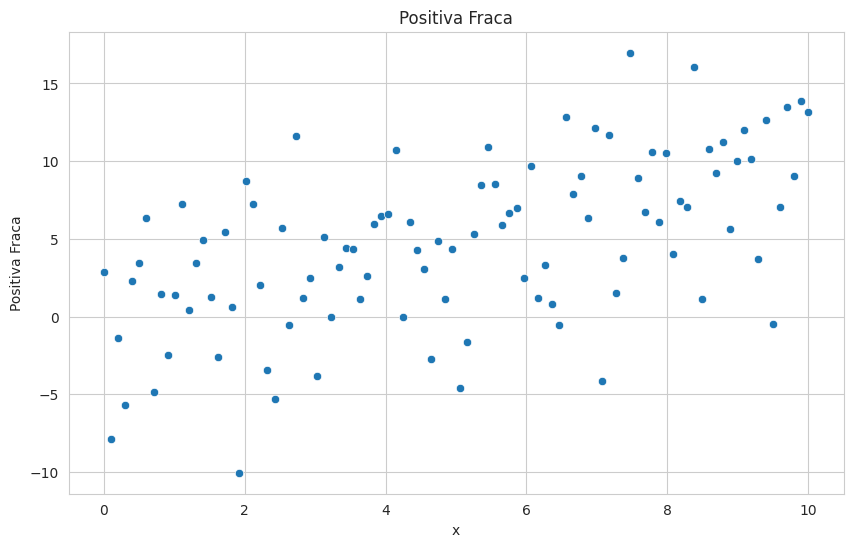

In [20]:
sns.scatterplot(data=dados_corr, x='x', y='Positiva Fraca').set_title('Positiva Fraca')
plt.show()


#### c) Negativa Forte

Quando a variável X aumenta, a variável Y diminui, e os pontos estão bem alinhados. Assim como na correlação positiva, também existe a variante 'Negativa Fraca', onde os pontos estariam mais espalhados.

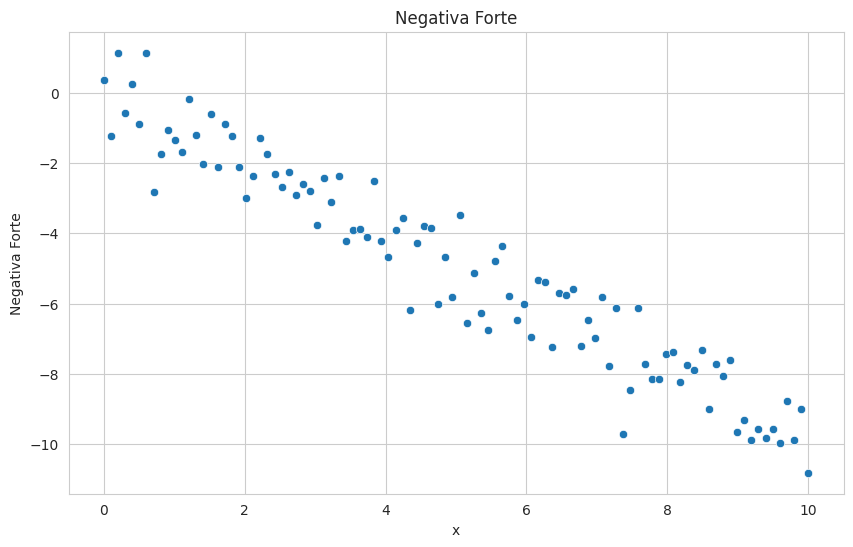

In [21]:
sns.scatterplot(data=dados_corr, x='x', y='Negativa Forte').set_title('Negativa Forte')
plt.show()



#### d) Sem Correlação

Não há nenhuma tendência aparente. Os pontos formam uma nuvem aleatória, indicando que as variáveis não estão relacionadas.

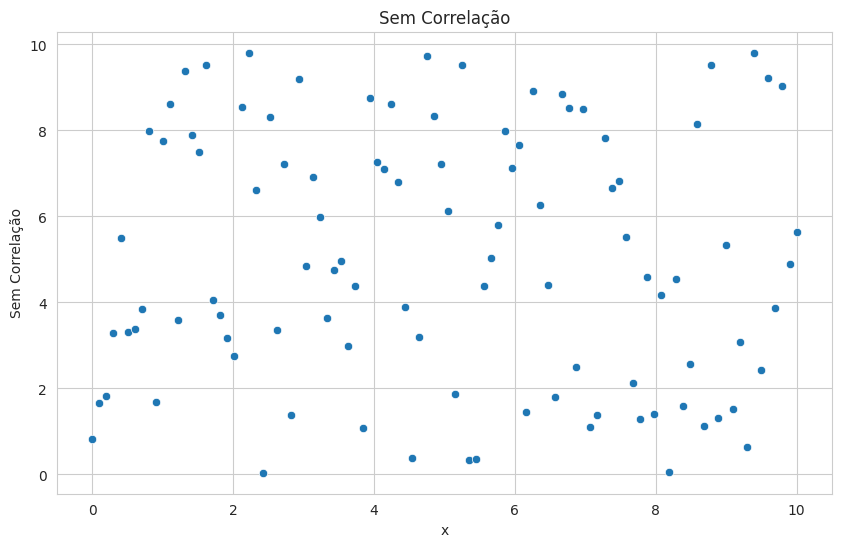

In [22]:
sns.scatterplot(data=dados_corr, x='x', y='Sem Correlação').set_title('Sem Correlação')
plt.show()


#### e) Correlação Não Linear

Existe uma relação clara e previsível entre X e Y, mas ela não segue uma linha reta. Neste caso, a relação é parabólica (em forma de "U").


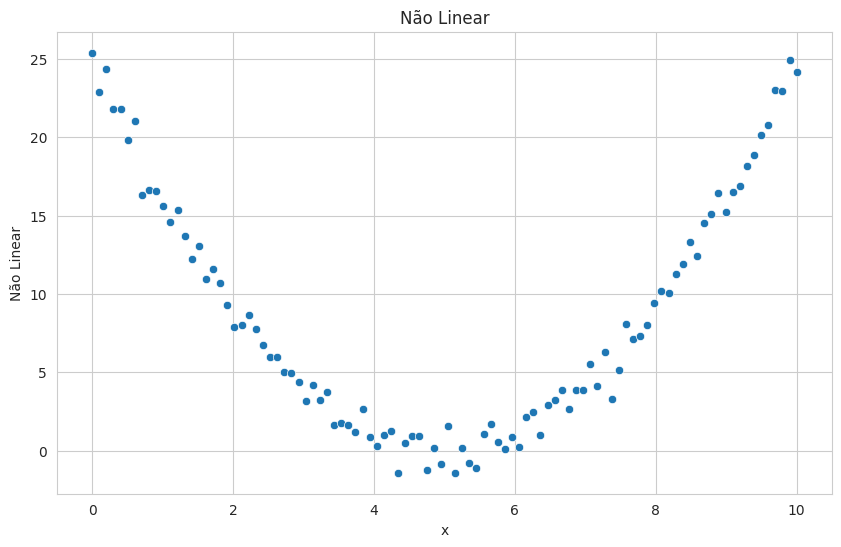

In [23]:
sns.scatterplot(data=dados_corr, x='x', y='Não Linear').set_title('Não Linear')
plt.show()


### 5.2. Relações na Pokédex

#### a) Ataque e Defesa

- **Correlação Positiva Fraca: `Attack` vs. `Defense`**

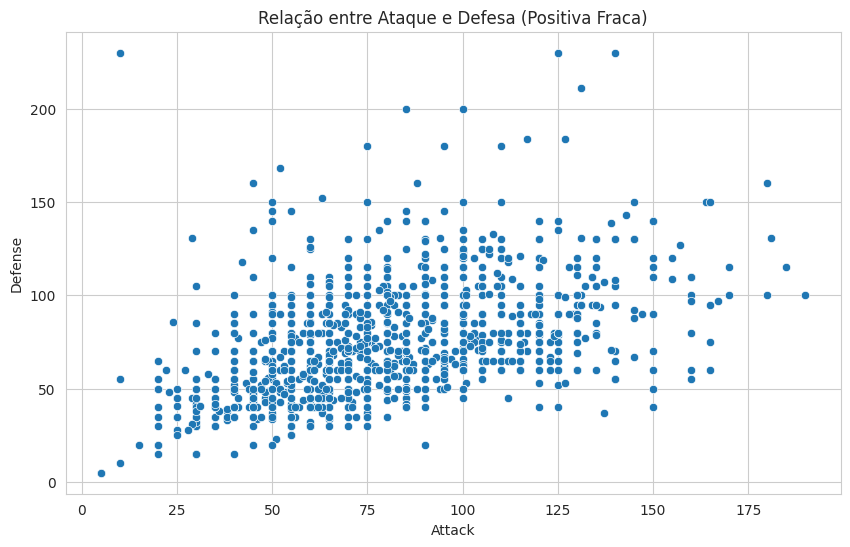

In [24]:
sns.scatterplot(data=df, x='Attack', y='Defense')
plt.title('Relação entre Ataque e Defesa (Positiva Fraca)')
plt.show()


Adicionando uma terceira dimensão com **cor**:




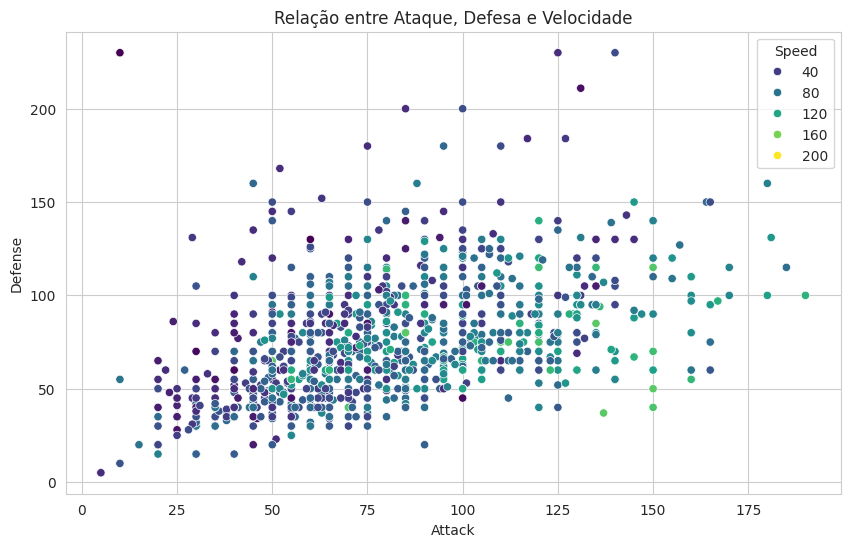

In [26]:
sns.scatterplot(data=df, x='Attack', y='Defense', hue='Speed', palette='viridis')
plt.title('Relação entre Ataque, Defesa e Velocidade')
plt.show()

#### b) Velocidade e Peso

- **Correlação Negativa Fraca: `Speed` vs. `Weight (hg)`** Nossa hipótese é que Pokémon mais pesados são mais lentos.

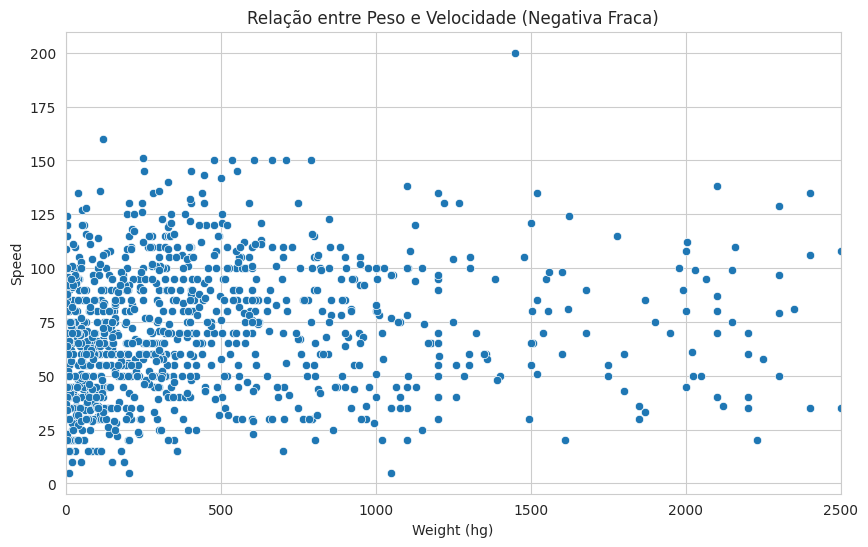

In [27]:
sns.scatterplot(data=df, x='Weight (hg)', y='Speed')
plt.title('Relação entre Peso e Velocidade (Negativa Fraca)')
plt.xlim(0, 2500) # Limitando o peso para melhor visualização
plt.show()

#### c) Número do Pokemon e Ataque

- **Sem Correlação: `National Dex #` vs. `Attack`** O número do Pokémon na Pokédex não deve ter relação com seu poder de ataque.


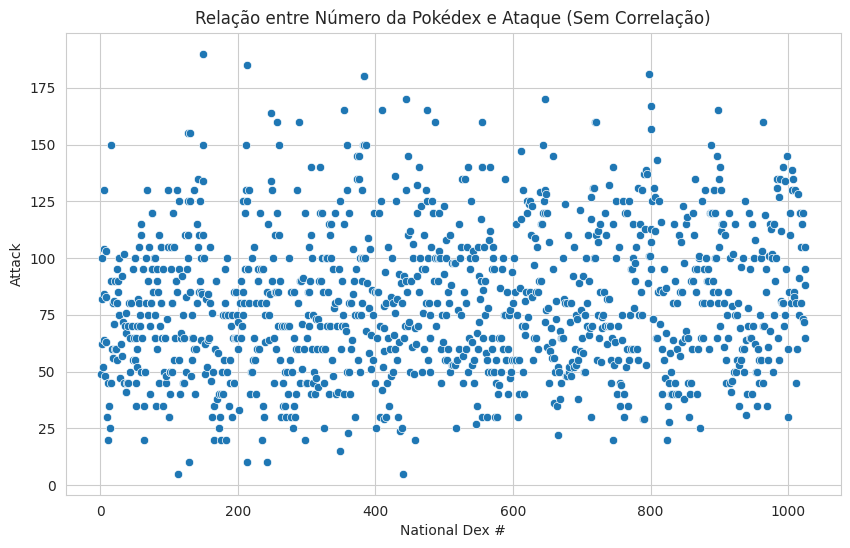

In [28]:
sns.scatterplot(data=df, x='National Dex #', y='Attack')
plt.title('Relação entre Número da Pokédex e Ataque (Sem Correlação)')
plt.show()

## 6. Hora dos Exercícios!

### Exercício 1: Distribuição de Velocidade

Crie um **histograma** para a coluna `Speed`. Descreva a forma do gráfico: ele é simétrico? Possui assimetria para algum lado? O que isso nos diz sobre a velocidade da maioria dos Pokémon?


### Exercício 2: Pokémon por Geração

O código deste exercício já foi apresentado na seção 4.3.a). Sua tarefa é executá-lo novamente e responder: Qual geração introduziu mais Pokémon, de acordo com o gráfico?


### Exercício 3: Proporção de Lendários

O código deste exercício já foi apresentado na seção 3.1. Sua tarefa é executá-lo novamente e responder: Você acha que este é um bom caso de uso para um gráfico de pizza? Justifique.


### Exercício 4: Relação entre Peso e Força

Crie um **gráfico de dispersão** para investigar a relação entre o peso (`Weight (hg)`) e a força total (`Base Stat Total`). Existe uma correlação clara? O que você pode concluir?
